<a href="https://colab.research.google.com/github/algroznykh/notebooks/blob/master/closed_form_texture_nca_rk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Closed-Form Neural Cellular Automata for Texture Synthesis

This notebook implements a **closed-form Neural Cellular Automaton** that synthesizes textures in O(1) time.
Instead of running a recurrent update loop for *T* steps, we solve the dynamics analytically in the frequency domain
using a matrix exponential, jumping directly to the state at any continuous time *t*.

**Architecture:** MLP Lift → Orthogonal Channel Mixing → Stable Diagonal Spatial Dynamics → MLP Projection

Key properties:
- **Marginal stability** — the spectral shift guarantees max eigenvalue = 0, preventing divergence even at *t* = 10000.
- **Resolution independence** — trained at 64×64, generates at arbitrary resolution via FFT zero-padding.
- **Exact recurrent equivalence** — the closed-form solution matches iterative RK4 simulation.

The model is trained with a VGG-based style loss on a target texture image.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import requests, io
from PIL import Image

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_default_device(device)
print(f'Using device: {device}')

Using device: cuda


## Style Loss

Gram-matrix loss at 5 VGG-19 layers (conv1_1 … conv5_1), plus a sliced optimal-transport variant using VGG-16.

In [2]:
class StyleLoss(nn.Module):
    """VGG-19 Gram-matrix style loss."""

    STYLE_LAYERS = [1, 6, 11, 20, 29]

    def __init__(self, target_img, device='cuda'):
        super().__init__()
        self.device = device
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1))

        vgg = torchvision.models.vgg19(weights='DEFAULT').features.to(device).eval()
        for p in vgg.parameters():
            p.requires_grad_(False)
        self.vgg = vgg

        with torch.no_grad():
            self.target_grams = self._extract_grams(target_img.unsqueeze(0).to(device))

    def _normalize(self, x):
        return (x - self.mean) / self.std

    def _extract_grams(self, x):
        x = self._normalize(x)
        grams = []
        for i, layer in enumerate(self.vgg):
            x = layer(x)
            if i in self.STYLE_LAYERS:
                b, c, h, w = x.shape
                F_map = x.reshape(b, c, -1)
                G = (F_map @ F_map.transpose(1, 2)) / (c * h * w)
                grams.append(G)
        return grams

    def forward(self, x):
        input_grams = self._extract_grams(x)
        return sum((ig - tg).pow(2).mean() for ig, tg in zip(input_grams, self.target_grams))

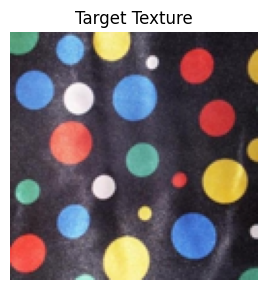

In [3]:
def imread(url, max_size=None, mode=None):
    if url.startswith(('http:', 'https:')):
        headers = {"User-Agent": "Requests/0.0"}
        r = requests.get(url, headers=headers)
        f = io.BytesIO(r.content)
    else:
        f = url
    img = Image.open(f)
    if max_size is not None:
        img.thumbnail((max_size, max_size))
    if mode is not None:
        img = img.convert(mode)
    return np.float32(img) / 255.0


url = 'https://www.robots.ox.ac.uk/~vgg/data/dtd/thumbs/dotted/dotted_0201.jpg'
target_texture = torch.tensor(imread(url, max_size=128)).permute(2, 1, 0).to(device)

plt.figure(figsize=(3, 3))
plt.imshow(target_texture.cpu().permute(1, 2, 0))
plt.title('Target Texture')
plt.axis('off')
plt.tight_layout()
plt.show()

In [4]:
vgg16 = models.vgg16(weights='IMAGENET1K_V1').features

def calc_styles_vgg(imgs):
    style_layers = [1, 6, 11, 18, 25]
    mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
    std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
    x = (imgs - mean) / std
    b, c, h, w = x.shape
    features = [x.reshape(b, c, h * w)]
    for i, layer in enumerate(vgg16[:max(style_layers) + 1]):
        x = layer(x)
        if i in style_layers:
            b, c, h, w = x.shape
            features.append(x.reshape(b, c, h * w))
    return features

def project_sort(x, proj):
    return torch.einsum('bcn,cp->bpn', x, proj).sort()[0]

def ot_loss(source, target, proj_n=32):
    ch, n = source.shape[-2:]
    projs = F.normalize(torch.randn(ch, proj_n), dim=0)
    source_proj = project_sort(source, projs)
    target_proj = project_sort(target, projs)
    target_interp = F.interpolate(target_proj, n, mode='nearest')
    return (source_proj - target_interp).square().sum()

def create_vgg_loss(target_img):
    yy = calc_styles_vgg(target_img)
    def loss_fn(imgs):
        xx = calc_styles_vgg(imgs)
        return sum(ot_loss(x, y) for x, y in zip(xx, yy))
    return loss_fn

with torch.no_grad():
    loss_f = create_vgg_loss(target_texture.unsqueeze(0))

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 199MB/s]


## Model

In [5]:
class ClosedFormNCA(nn.Module):
    """
    Closed-form NCA with orthogonal channel mixing and marginal stability.
    The spectral shift forces max eigenvalue to 0, preventing divergence at any t.
    """

    def __init__(self, in_ch=3, latent_ch=48, default_grid_size=64, hidden=64, update_rate=0.5):
        super().__init__()
        self.in_ch = in_ch
        self.C = latent_ch
        self.default_grid = default_grid_size
        self.update_rate = update_rate

        self.lift = nn.Sequential(
            nn.Conv2d(in_ch, hidden, 3, padding=1, padding_mode='circular'), nn.GELU(),
            nn.Conv2d(hidden, hidden, 3, padding=1, padding_mode='circular'), nn.GELU(),
            nn.Conv2d(hidden, hidden, 3, padding=1, padding_mode='circular'), nn.GELU(),
            nn.Conv2d(hidden, hidden, 3, padding=1, padding_mode='circular'), nn.GELU(),
            nn.Conv2d(hidden, hidden, 3, padding=1, padding_mode='circular'), nn.GELU(),
            nn.Conv2d(hidden, hidden, 3, padding=1, padding_mode='circular'), nn.GELU(),
            nn.Conv2d(hidden, latent_ch, 3, padding=1, padding_mode='circular'),
        )

        self.project = nn.Sequential(
            nn.Conv2d(latent_ch, hidden, 1), nn.GELU(),
            nn.Conv2d(hidden, hidden, 1), nn.GELU(),
            nn.Conv2d(hidden, hidden, 1), nn.GELU(),
            nn.Conv2d(hidden, hidden, 1), nn.GELU(),
            nn.Conv2d(hidden, hidden, 1), nn.GELU(),
            nn.Conv2d(hidden, hidden, 1), nn.GELU(),
            nn.Conv2d(hidden, in_ch, 1), nn.Sigmoid(),
        )

        # Orthogonal channel mixing via skew-symmetric exponential
        self.U_raw = nn.Parameter(torch.randn(latent_ch, latent_ch) * 0.1)
        # Unconstrained 3x3 depthwise spatial kernel
        self.spatial_kernel = nn.Parameter(torch.randn(latent_ch, 1, 3, 3) * 0.1)

    @property
    def device(self):
        return self.U_raw.device

    def _get_U(self):
        skew = self.U_raw - self.U_raw.T
        return torch.matrix_exp(skew)

    def _get_stable_dynamics(self, H, W):
        """Compute spectrally-shifted frequency response and stabilized kernel."""
        k_pad = F.pad(self.spatial_kernel, (0, W - 3, 0, H - 3))
        k_pad = torch.roll(k_pad, shifts=(-1, -1), dims=(2, 3))
        g_hat = torch.fft.fft2(k_pad).squeeze(1)

        max_real = g_hat.real.amax(dim=(1, 2), keepdim=True)
        g_hat_stable = (g_hat.real - max_real) + 1j * g_hat.imag

        k_stable = self.spatial_kernel.clone()
        k_stable[:, 0, 1, 1] = k_stable[:, 0, 1, 1] - max_real.squeeze()
        return g_hat_stable, k_stable

    def _sample_noise(self, batch_size=1, H=None, W=None):
        H = H or self.default_grid
        W = W or self.default_grid
        return torch.randn(batch_size, self.in_ch, H, W, device=self.device)

    # ---- Closed-form forward pass ----

    def forward(self, t, x0=None, batch_size=1):
        """Compute output at continuous time t in O(1) via frequency-domain matrix exponential."""
        if x0 is None:
            x0 = self._sample_noise(batch_size)
        elif x0.dim() == 3:
            x0 = x0.unsqueeze(0)

        H, W = x0.shape[2:]
        X0 = torch.fft.fft2(self.lift(x0))
        U = self._get_U()
        g_hat_stable, _ = self._get_stable_dynamics(H, W)

        if not isinstance(t, torch.Tensor):
            t = torch.tensor(t, device=self.device)
        t = t.view(-1, 1, 1, 1).to(self.device)

        X_z = torch.einsum('cd, bdhw -> bchw', U.T.to(X0.dtype), X0)
        X_zt = X_z * torch.exp(t * self.update_rate * g_hat_stable.unsqueeze(0))
        Xt = torch.einsum('cd, bdhw -> bchw', U.to(X_zt.dtype), X_zt)

        return self.project(torch.fft.ifft2(Xt).real)

    # ---- Recurrent stepping (for comparison / video) ----

    def _get_stable_kernel_local(self):
        """Stabilize the 3x3 kernel on a small reference grid (resolution-independent)."""
        k = self.spatial_kernel
        REF = 8
        k_pad = F.pad(k, (0, REF - 3, 0, REF - 3))
        k_pad = torch.roll(k_pad, shifts=(-1, -1), dims=(2, 3))
        g_hat = torch.fft.fft2(k_pad).squeeze(1)
        max_real = g_hat.real.amax(dim=(1, 2))
        k_stable = k.clone()
        k_stable[:, 0, 1, 1] = k_stable[:, 0, 1, 1] - max_real
        return k_stable

    def step_latent(self, state_latent, dt=0.5):
        """Single RK4 step in latent space with stochastic update mask."""
        if state_latent.dim() == 3:
            state_latent = state_latent.unsqueeze(0)

        def dynamics(x):
            U = self._get_U()
            _, k_stable = self._get_stable_dynamics(x.shape[2], x.shape[3])
            z = F.conv2d(x, U.T.unsqueeze(-1).unsqueeze(-1))
            z_pad = F.pad(z, (1, 1, 1, 1), mode='circular')
            delta_z = F.conv2d(z_pad, k_stable, groups=self.C)
            return F.conv2d(delta_z, U.unsqueeze(-1).unsqueeze(-1))

        h = dt
        k1 = dynamics(state_latent)
        k2 = dynamics(state_latent + 0.5 * h * k1)
        k3 = dynamics(state_latent + 0.5 * h * k2)
        k4 = dynamics(state_latent + h * k3)

        mask = (torch.rand(
            state_latent.shape[0], 1,
            state_latent.shape[2], state_latent.shape[3],
            device=state_latent.device
        ) < self.update_rate).float()

        delta = (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4) * mask
        return state_latent + delta

    def get_initial_latent(self, x0=None, batch_size=1):
        if x0 is None:
            x0 = self._sample_noise(batch_size)
        elif x0.dim() == 3:
            x0 = x0.unsqueeze(0)
        return self.lift(x0).detach().clone()

## Training

In [22]:
from tqdm import tqdm

def train_nca():
    batch_size = 16
    iterations = 3000
    lr = 1e-3
    t_min, t_max = 32.0, 256.0
    GRID = 64
    LAT, HID, UPD = 48, 24, 0.5

    model = ClosedFormNCA(
        in_ch=3, latent_ch=LAT, hidden=HID,
        default_grid_size=GRID, update_rate=UPD
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    pbar = tqdm(range(iterations))
    for step in pbar:
        optimizer.zero_grad()

        x0 = torch.randn(batch_size, 3, GRID, GRID, device=device)
        t = torch.empty(batch_size, device=device).uniform_(t_min, t_max)
        pred = model(t, x0=x0)

        loss = loss_f(pred)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        if step % 10 == 0:
            pbar.set_description(f'Loss: {loss.item():.4f}')

    return model

model = train_nca()

Loss: 373988.2500: 100%|██████████| 3000/3000 [01:40<00:00, 29.84it/s]


## Evaluation

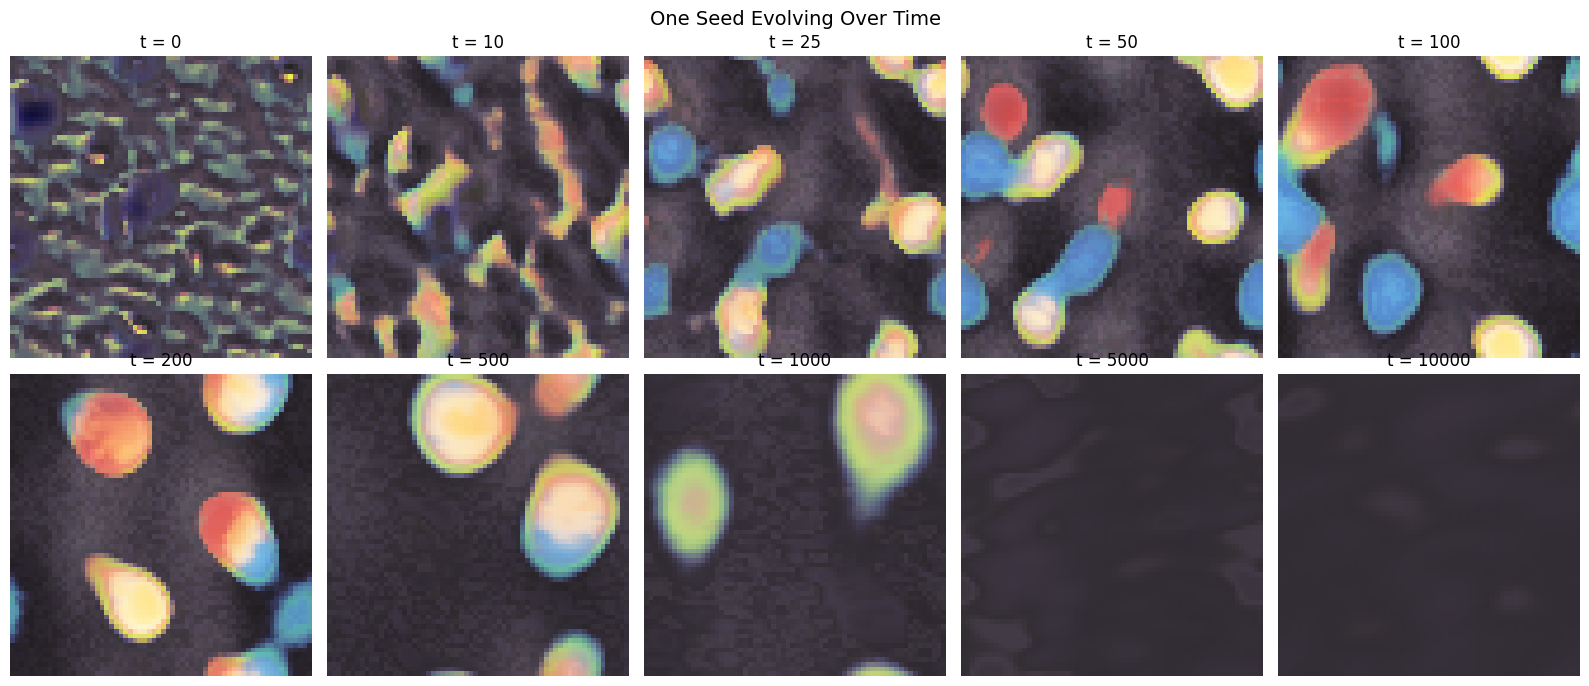

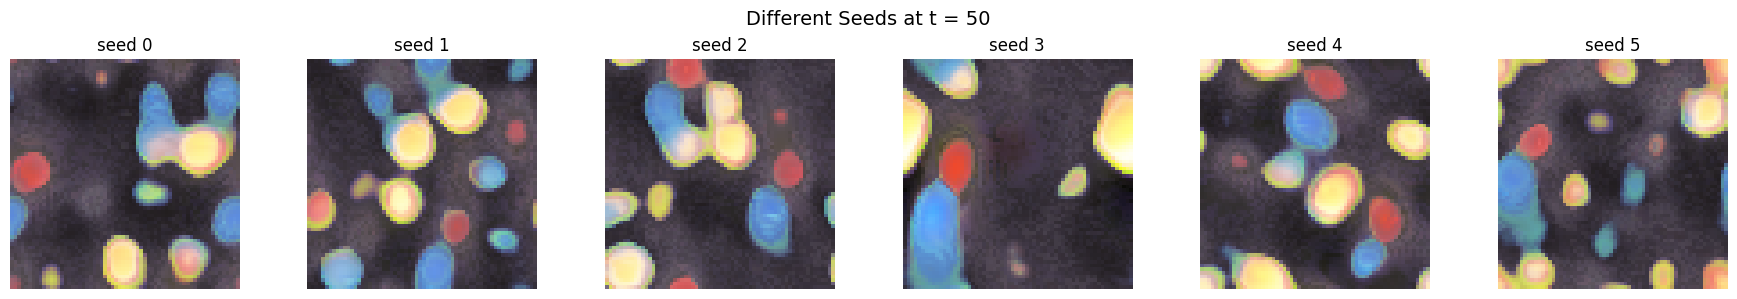

In [23]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
eval_times = [0, 10, 25, 50, 100, 200, 500, 1000, 5000, 10000]

torch.manual_seed(0)
noise_seed = model._sample_noise()

with torch.no_grad():
    for i, t in enumerate(eval_times):
        row, col = divmod(i, 5)
        pred = model(float(t), x0=noise_seed)
        axes[row, col].imshow(pred[0].cpu().permute(1, 2, 0).clamp(0, 1))
        axes[row, col].set_title(f't = {t}')
        axes[row, col].axis('off')

plt.suptitle('One Seed Evolving Over Time', fontsize=14)
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 6, figsize=(18, 3))
with torch.no_grad():
    for i in range(6):
        pred = model(50.0)
        axes2[i].imshow(pred[0].cpu().permute(1, 2, 0).clamp(0, 1))
        axes2[i].set_title(f'seed {i}')
        axes2[i].axis('off')
plt.suptitle('Different Seeds at t = 50', fontsize=14)
plt.tight_layout()
plt.show()

## Recurrent vs Closed-Form Comparison

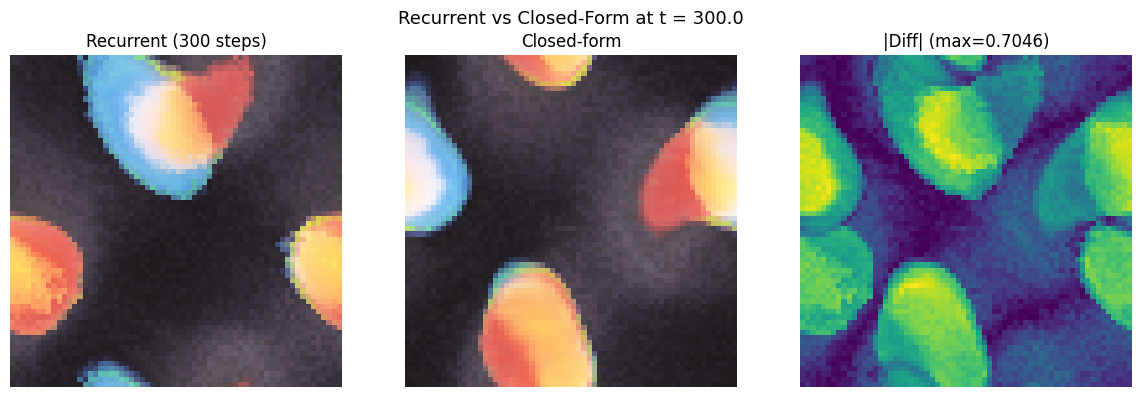

In [24]:
with torch.no_grad():
    T_compare = 300.0
    dt = 1.0
    n_steps = int(T_compare / dt)

    noise_0 = model._sample_noise()

    # Recurrent RK4 simulation
    state = model.get_initial_latent(x0=noise_0)
    for _ in range(n_steps):
        state = model.step_latent(state, dt=dt)
    rec_rgb = model.project(state)[0]

    # Closed-form O(1) jump
    cf_rgb = model(T_compare, x0=noise_0)[0]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(rec_rgb.cpu().permute(1, 2, 0).clamp(0, 1))
    axes[0].set_title(f'Recurrent ({n_steps} steps)')
    axes[0].axis('off')

    axes[1].imshow(cf_rgb.cpu().permute(1, 2, 0).clamp(0, 1))
    axes[1].set_title('Closed-form')
    axes[1].axis('off')

    diff = (rec_rgb - cf_rgb).abs().mean(0)
    axes[2].imshow(diff.cpu(), cmap='viridis')
    axes[2].set_title(f'|Diff| (max={diff.max():.4f})')
    axes[2].axis('off')

    plt.suptitle(f'Recurrent vs Closed-Form at t = {T_compare}', fontsize=13)
    plt.tight_layout()
    plt.show()

## Video Rendering

In [25]:
from moviepy.video.io.ffmpeg_writer import FFMPEG_VideoWriter
import moviepy.editor as mvp

VIDEO_SIZE = 256
VIDEO_FPS = 30
VIDEO_SECONDS = 20
VIDEO_DT = 1.0
n_frames = VIDEO_FPS * VIDEO_SECONDS
out_path = 'texture_nca.mp4'

with torch.no_grad():
    noise_v = model._sample_noise(batch_size=1, H=VIDEO_SIZE, W=VIDEO_SIZE)

    with FFMPEG_VideoWriter(out_path, (VIDEO_SIZE, VIDEO_SIZE), VIDEO_FPS) as writer:
        for i in range(n_frames):
            t = i * VIDEO_DT
            rgb = model(t, x0=noise_v)[0]
            frame = rgb.clamp(0, 1).permute(1, 2, 0).cpu().numpy()
            writer.write_frame((frame * 255).astype(np.uint8))

print(f'Rendered {n_frames} frames -> {out_path}')
mvp.ipython_display(out_path, maxduration=60)

Rendered 600 frames -> texture_nca.mp4
